# EDA: Facturación, Clientes y Churn

## Caso Práctico - Empresa de Telecomunicaciones
## MBI — Prácticas Aplicadas 2026

---

En este notebook analizamos la tabla de facturación mensual junto con el perfil de clientes y la variable objetivo de churn.

La facturación es una fuente de datos muy rica: no solo nos dice cuánto paga cada cliente, sino también cómo varía su consumo mes a mes, si tiene impagos, si recibe descuentos... Todo eso puede ser una señal de comportamiento que precede al abandono.

**Fuentes de datos:**
- `facturacion_mensual.csv` → Panel cliente-mes con importes, consumos, pagos y señales de calidad
- `clientes.csv` → Perfil estático del cliente
- `churn_target.csv` → Panel cliente-mes con la etiqueta de abandono


## Objetivos del notebook

1. Explorar la estructura y calidad de `facturacion_mensual.csv`
2. Detectar problemas de calidad: fechas con formato mixto, nulos, valores imposibles
3. Construir una tabla analítica por cliente agregando la facturación
4. Contrastar hipótesis sobre la relación entre facturación y churn:
   - **H1**: ¿Los clientes que más pagan abandonan más o menos?
   - **H2**: ¿Los clientes con consumo extra alto tienen menos churn (más engagement)?
   - **H3**: ¿Los impagos o retrasos en el pago son señal de churn próximo?
   - **H4**: ¿Una caída brusca en el consumo justo antes del churn es un indicador adelantado?
   - **H5**: ¿Los clientes con descuento aplicado abandonan menos?
   - **H6**: ¿El estrés de calidad de red (stress_calidad_lag) está relacionado con el churn?
   - **H7**: ¿El tipo de plan (Prepago / Contrato / Premium) tiene distinta tasa de churn?


## Nota metodológica

Al igual que con el soporte, la facturación es una tabla en panel (cliente-mes), así que para cruzarla con el perfil de cliente tenemos que agregarla primero.

Para el EDA usaremos la etiqueta `ever_churn = 1` si el cliente churneó en algún momento del horizonte observado.

⚠️ **Leakage**: Algunas variables de facturación (impagos, caída de consumo) pueden ocurrir justo antes o durante el mes del churn. En el modelado habría que usar lags para no filtrar información futura. Aquí lo mencionamos pero no nos preocupa para el EDA exploratorio.


## 1. Librerías


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, chi2_contingency

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
PAL = {'No Churn': '#4C9BE8', 'Churn': '#E85C4C'}

print('Librerías cargadas')

Librerías cargadas


## 2. Funciones auxiliares


In [2]:
def resumen_df(df, nombre='DataFrame'):
    print(f"\n{'='*50}")
    print(f" RESUMEN: {nombre}")
    print(f"{'='*50}")
    print(f"  Filas:      {df.shape[0]:,}")
    print(f"  Columnas:   {df.shape[1]}")
    print(f"  Duplicados: {df.duplicated().sum():,}")
    info = pd.DataFrame({
        'dtype': df.dtypes,
        'n_nulos': df.isnull().sum(),
        'pct_nulos': (df.isnull().mean() * 100).round(2)
    })
    display(info)


def boxplot_churn(df, variable, titulo=None):
    """Boxplot de una variable numérica comparando churners vs no churners."""
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.boxplot(data=df, x='churn_label', y=variable,
                order=['No Churn', 'Churn'], palette=PAL, ax=ax)
    ax.set_title(titulo or f'{variable} vs Churn', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(variable)
    plt.tight_layout()
    plt.show()


def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    return round(v, 3), round(p, 4)


def test_mw(df, variable):
    """Mann-Whitney entre churners y no churners para una variable numérica."""
    a = df[df['ever_churn'] == 0][variable].dropna()
    b = df[df['ever_churn'] == 1][variable].dropna()
    u, p = mannwhitneyu(a, b, alternative='two-sided')
    print(f"Mann-Whitney ({variable}): p={p:.4f}")
    print(f"  Mediana No Churn: {a.median():.2f} | Mediana Churn: {b.median():.2f}")


print('Funciones definidas')

Funciones definidas


## 3. Carga de datos


In [6]:

path_clientes = '../data/raw/clientes.csv'
path_churn = '../data/raw/churn_target.csv'
path_factura = '../data/raw/facturacion_mensual.csv'

# Cargamos los tres ficheros del caso
clientes = pd.read_csv(path_clientes)
churn = pd.read_csv(path_churn)
factura= pd.read_csv(path_factura)


# Fechas: la columna fecha tiene formatos mixtos (YYYY-MM-DD y DD/MM/YYYY)
# usamos dayfirst=True para manejar ambos
churn['fecha']   = pd.to_datetime(churn['fecha'], format='mixed', dayfirst=True)
factura['fecha'] = pd.to_datetime(factura['fecha'], format='mixed', dayfirst=True)

print(f'clientes:    {clientes.shape[0]:,} filas x {clientes.shape[1]} columnas')
print(f'churn:       {churn.shape[0]:,} filas x {churn.shape[1]} columnas')
print(f'facturacion: {factura.shape[0]:,} filas x {factura.shape[1]} columnas')

clientes:    10,150 filas x 14 columnas
churn:       321,987 filas x 3 columnas
facturacion: 326,816 filas x 14 columnas


---
## 4. EDA — Tabla de Facturación

Antes de cruzar nada, exploramos la tabla de facturación por sí sola: estructura, distribuciones y problemas de calidad.


In [7]:
resumen_df(factura, 'facturacion_mensual.csv')
display(factura.head())


 RESUMEN: facturacion_mensual.csv
  Filas:      326,816
  Columnas:   14
  Duplicados: 4,829


,dtype,n_nulos,pct_nulos
cliente_id,object,0,0.00
fecha,datetime64[ns],0,0.00
zona_id,object,0,0.00
tipo_plan,object,9816,3.00
num_lineas,int64,0,0.00
cargo_base,float64,0,0.00
consumo_extra,float64,0,0.00
descuento_aplicado,float64,0,0.00
importe_total,float64,9799,3.00
dias_retraso_pago,int64,0,0.00


,cliente_id,fecha,zona_id,tipo_plan,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag
0,C000001,2023-01-01,Z26,Prepago,2,43.65,6.98,0.00,50.62,0,0,0.00,0.00,0
1,C000001,2023-02-01,Z26,Prepago,2,43.65,10.33,0.00,53.98,0,0,0.48,0.41,0
2,C000001,2023-03-01,Z26,Prepago,2,43.65,10.87,0.00,54.52,0,0,0.05,0.42,0
3,C000001,2023-04-01,Z26,Prepago,2,43.65,6.82,0.00,50.47,0,0,-0.37,0.43,0
4,C000001,2023-05-01,Z26,Prepago,2,43.65,13.26,0.00,56.90,0,0,0.94,0.45,0


In [8]:
display(factura.describe())

,fecha,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag
count,326816,"326,816.00","326,816.00","326,816.00","326,816.00","317,017.00","326,816.00","326,816.00","326,816.00","326,816.00","326,816.00"
mean,2024-05-25 14:48:30.261431552,2.31,126.51,6.86,6.46,127.14,3.31,0.10,0.41,0.40,0.00
min,2023-01-01 00:00:00,1.00,15.01,-42.08,0.00,11.28,0.00,0.00,-1.00,0.00,0.00
25%,2023-09-01 00:00:00,2.00,52.21,0.00,0.00,59.68,0.00,0.00,-0.32,0.29,0.00
50%,2024-05-01 00:00:00,2.00,113.10,5.31,0.00,109.87,0.00,0.00,0.00,0.39,0.00
75%,2025-03-01 00:00:00,3.00,174.89,11.41,4.26,174.34,0.00,0.00,0.39,0.50,0.00
max,2025-12-01 00:00:00,5.00,449.84,54.01,112.25,483.66,"1,100.00",1.00,19.65,0.80,1.00
std,NaN,1.01,85.89,7.33,13.85,82.75,22.52,0.30,1.67,0.17,0.06


### 4.1 Control de calidad

Ya de entrada hay varias cosas sospechosas en los datos que merece la pena documentar antes de seguir.


In [9]:
quality = {
    'filas_duplicadas':                   int(factura.duplicated().sum()),
    'duplicado_cliente_fecha':            int(factura.duplicated(subset=['cliente_id','fecha']).sum()),
    'importe_total_nulo':                 int(factura['importe_total'].isnull().sum()),
    'importe_total_negativo':             int((factura['importe_total'] < 0).sum()),
    'consumo_extra_negativo':             int((factura['consumo_extra'] < 0).sum()),
    'tipo_plan_nulo':                     int(factura['tipo_plan'].isnull().sum()),
    'descuento_aplicado_negativo':        int((factura['descuento_aplicado'] < 0).sum()),
    'dias_retraso_negativo':              int((factura['dias_retraso_pago'] < 0).sum()),
    'stress_calidad_fuera_rango (>1)':    int((factura['stress_calidad_lag'] > 1).sum()),
}

qdf = pd.DataFrame.from_dict(quality, orient='index', columns=['n_casos'])
qdf['alerta'] = qdf['n_casos'].apply(lambda x: '⚠️' if x > 0 else '✅')
display(qdf)

# Ver un ejemplo de consumo_extra negativo (probablemente ajuste o abono)
print("\nEjemplos de consumo_extra negativo:")
display(factura[factura['consumo_extra'] < 0][['cliente_id','fecha','cargo_base','consumo_extra','importe_total']].head())

,n_casos,alerta
filas_duplicadas,4829,⚠️
duplicado_cliente_fecha,4829,⚠️
importe_total_nulo,9799,⚠️
importe_total_negativo,0,✅
consumo_extra_negativo,3684,⚠️
tipo_plan_nulo,9816,⚠️
descuento_aplicado_negativo,0,✅
dias_retraso_negativo,0,✅
stress_calidad_fuera_rango (>1),0,✅



Ejemplos de consumo_extra negativo:


,cliente_id,fecha,cargo_base,consumo_extra,importe_total
74,C000003,2023-03-01,46.19,-8.64,54.83
107,C000004,2023-05-01,21.45,-21.03,42.48
119,C000004,2024-05-01,21.45,-12.44,33.89
154,C000005,2024-04-01,91.59,-3.03,94.62
310,C000009,2025-04-01,347.42,-23.16,NaN


Hay algunas incidencias a tener en cuenta:
- **`importe_total` nulo**: en algunos registros no se tiene el importe final. Habrá que decidir si imputar o eliminar esas filas en el modelado.
- **`consumo_extra` negativo**: probablemente son abonos o correcciones. No es necesariamente un error, pero hay que tratarlo con cuidado.
- **`tipo_plan` nulo**: algunos meses no tienen plan registrado. Puede ser un problema de carga del sistema.
- **Fechas con formato mixto**: el CSV mezcla `YYYY-MM-DD` y `DD/MM/YYYY`. Hay que parsearlo con cuidado para no introducir errores de fechas.


### 4.2 Distribución de las variables de facturación


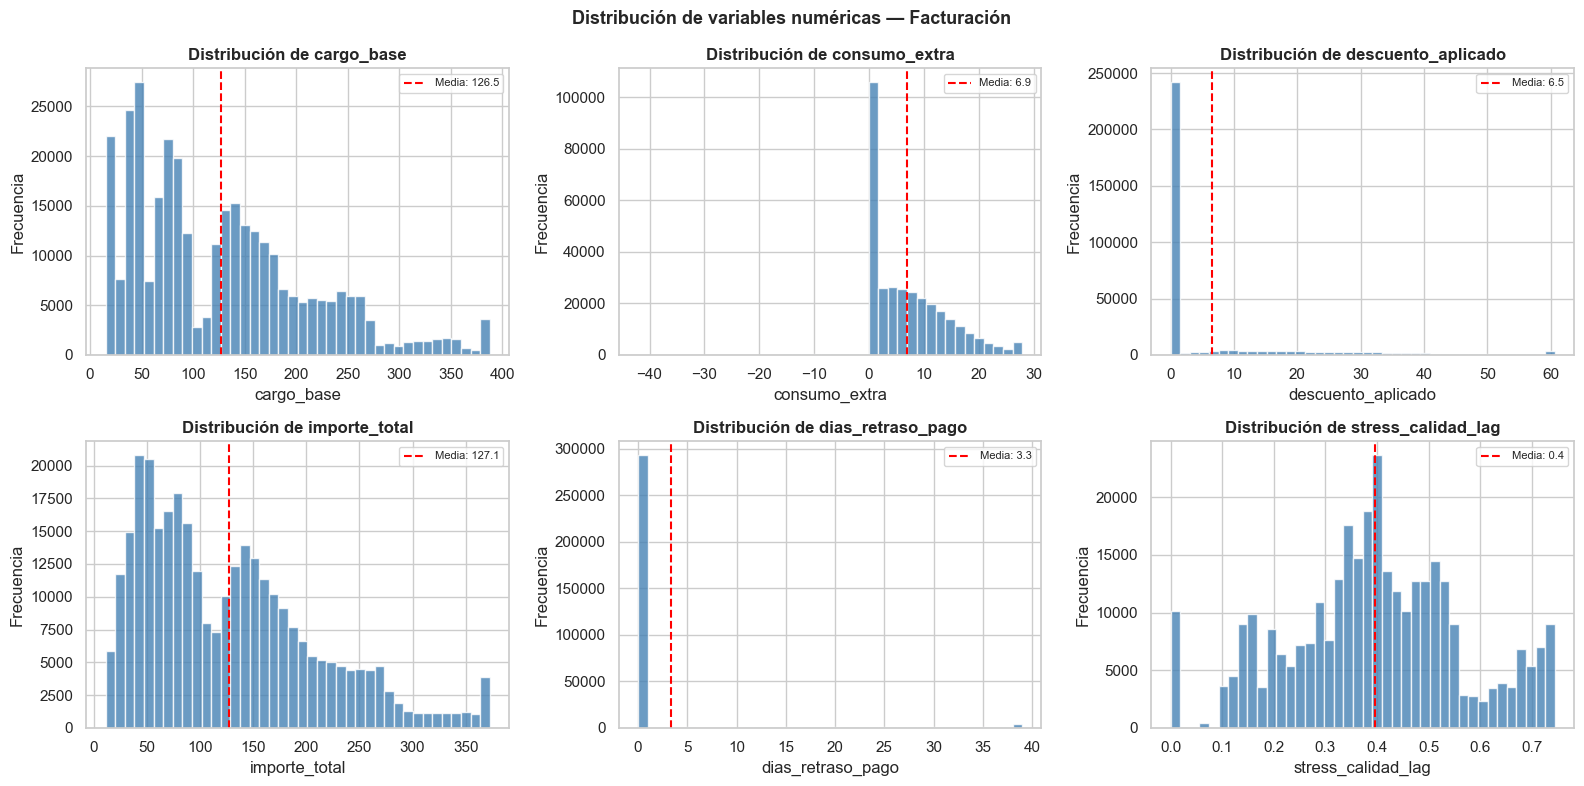

In [10]:
vars_num = ['cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total', 
            'dias_retraso_pago', 'stress_calidad_lag']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(vars_num):
    datos = factura[col].dropna()
    # Recortamos outliers extremos para ver mejor la distribución
    p99 = datos.quantile(0.99)
    datos_clip = datos.clip(upper=p99)
    axes[i].hist(datos_clip, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    media = datos.mean()
    axes[i].axvline(media, color='red', linestyle='--', label=f'Media: {media:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas — Facturación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

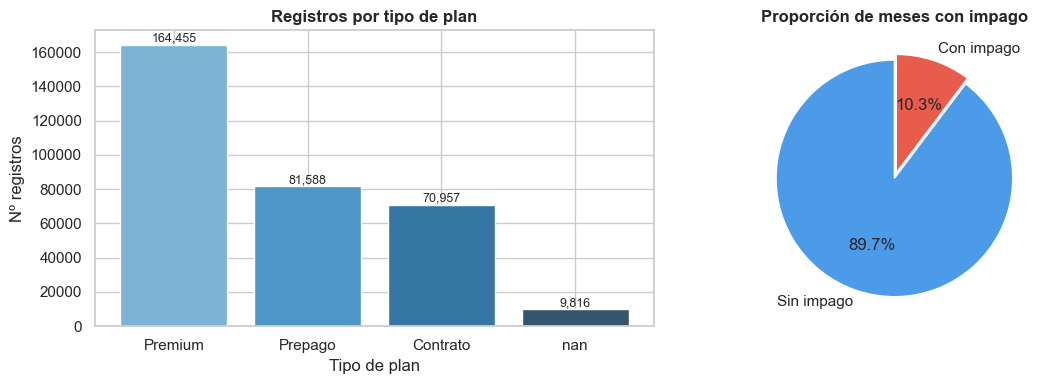


Tasa global de impago (% meses con impago_flag=1): 10.3%


In [11]:
# Distribución por tipo de plan e impago
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plan_counts = factura['tipo_plan'].value_counts(dropna=False)
axes[0].bar(plan_counts.index.astype(str), plan_counts.values,
            color=sns.color_palette('Blues_d', len(plan_counts)))
axes[0].set_title('Registros por tipo de plan', fontweight='bold')
axes[0].set_ylabel('Nº registros')
axes[0].set_xlabel('Tipo de plan')
for bar, val in zip(axes[0].patches, plan_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

impago_counts = factura['impago_flag'].value_counts()
axes[1].pie(impago_counts.values, labels=['Sin impago', 'Con impago'],
            autopct='%1.1f%%', colors=['#4C9BE8', '#E85C4C'],
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Proporción de meses con impago', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTasa global de impago (% meses con impago_flag=1): {factura['impago_flag'].mean()*100:.1f}%")

### 4.3 Evolución temporal de la facturación

Como es un panel temporal, interesa ver si hay tendencias o estacionalidad en los importes y en los impagos.


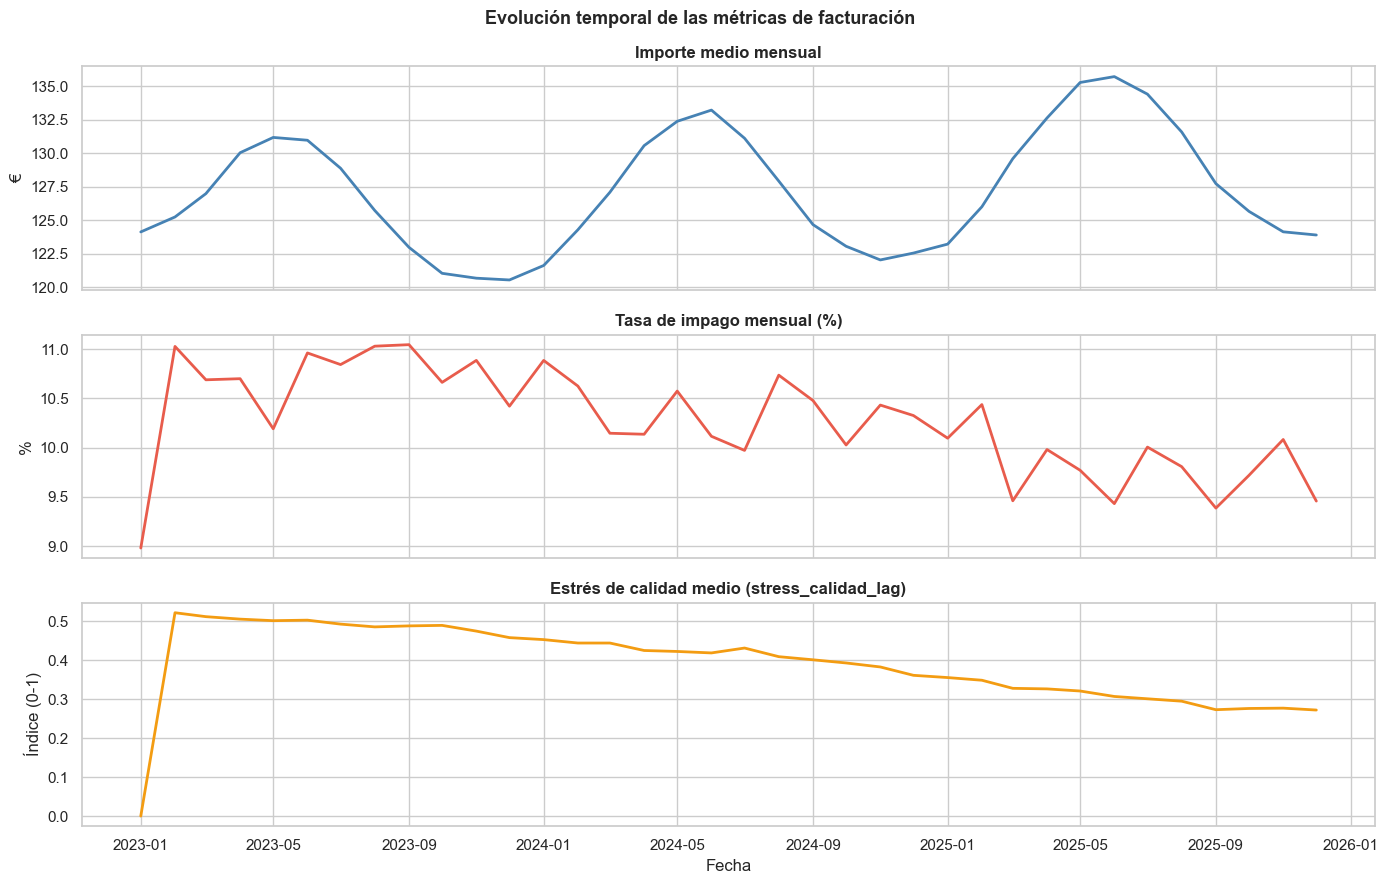

In [12]:
evol = factura.groupby('fecha').agg(
    importe_medio=('importe_total', 'mean'),
    tasa_impago=('impago_flag', 'mean'),
    stress_medio=('stress_calidad_lag', 'mean')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(evol['fecha'], evol['importe_medio'], color='steelblue', linewidth=2)
axes[0].set_title('Importe medio mensual', fontweight='bold')
axes[0].set_ylabel('€')

axes[1].plot(evol['fecha'], evol['tasa_impago'] * 100, color='#E85C4C', linewidth=2)
axes[1].set_title('Tasa de impago mensual (%)', fontweight='bold')
axes[1].set_ylabel('%')

axes[2].plot(evol['fecha'], evol['stress_medio'], color='#f39c12', linewidth=2)
axes[2].set_title('Estrés de calidad medio (stress_calidad_lag)', fontweight='bold')
axes[2].set_ylabel('Índice (0-1)')
axes[2].set_xlabel('Fecha')

plt.suptitle('Evolución temporal de las métricas de facturación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Construcción de la tabla analítica

Agregamos la facturación por cliente y la unimos con el perfil de clientes y el churn.


In [14]:
# --- Agregamos churn a nivel cliente ---
churn_agg = churn.groupby('cliente_id').agg(
    ever_churn=('churn', 'max'),
    n_meses_observados=('churn', 'count')
).reset_index()

# --- Agregamos facturación a nivel cliente ---
factura_agg = factura.groupby('cliente_id').agg(
    importe_medio=('importe_total', 'mean'),
    importe_total_sum=('importe_total', 'sum'),
    cargo_base_medio=('cargo_base', 'mean'),
    consumo_extra_medio=('consumo_extra', 'mean'),
    descuento_medio=('descuento_aplicado', 'mean'),
    pct_meses_descuento=('descuento_aplicado', lambda x: (x > 0).mean()),
    n_impagos=('impago_flag', 'sum'),
    pct_meses_impago=('impago_flag', 'mean'),
    dias_retraso_medio=('dias_retraso_pago', 'mean'),
    dias_retraso_max=('dias_retraso_pago', 'max'),
    stress_medio=('stress_calidad_lag', 'mean'),
    stress_max=('stress_calidad_lag', 'max'),
    n_incidencias_masivas=('incidencia_masiva_lag', 'sum'),
    variacion_consumo_media=('variacion_consumo_pct', 'mean'),
    n_meses_facturados=('importe_total', 'count')
).reset_index()

# Plan más frecuente por cliente (el que aparece más meses)
plan_dominante = (factura.dropna(subset=['tipo_plan'])
                  .groupby('cliente_id')['tipo_plan']
                  .agg(lambda x: x.value_counts().index[0])
                  .reset_index()
                  .rename(columns={'tipo_plan': 'plan_dominante'}))

factura_agg = factura_agg.merge(plan_dominante, on='cliente_id', how='left')

# --- Tabla final: clientes + churn + facturación ---
df = clientes.merge(churn_agg, on='cliente_id', how='inner')
df = df.merge(factura_agg, on='cliente_id', how='left')

# Columna con etiqueta legible para los gráficos
df['churn_label'] = df['ever_churn'].map({0: 'No Churn', 1: 'Churn'})

print(f"Tabla analítica: {df.shape[0]:,} clientes x {df.shape[1]} columnas")
print(f"Clientes con ever_churn=1: {df['ever_churn'].sum():,} ({df['ever_churn'].mean()*100:.1f}%)")

display(df.head())

Tabla analítica: 10,150 clientes x 33 columnas
Clientes con ever_churn=1: 2,023 (19.9%)


,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,ever_churn,n_meses_observados,importe_medio,importe_total_sum,cargo_base_medio,consumo_extra_medio,descuento_medio,pct_meses_descuento,n_impagos,pct_meses_impago,dias_retraso_medio,dias_retraso_max,stress_medio,stress_max,n_incidencias_masivas,variacion_consumo_media,n_meses_facturados,plan_dominante,churn_label
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0,0,36,52.59,"1,945.71",43.65,8.94,0.00,0.00,3,0.08,2.65,46,0.27,0.45,0,0.53,37,Prepago,No Churn
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1,0,36,120.71,"4,586.98",142.24,3.90,25.43,1.00,4,0.11,3.74,45,0.44,0.57,0,0.82,38,Premium,No Churn
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0,1,31,52.45,"1,625.97",46.19,5.70,0.00,0.00,5,0.16,4.35,38,0.45,0.57,1,0.54,31,Prepago,Churn
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0,0,36,27.33,956.57,21.45,4.07,0.00,0.00,3,0.08,2.36,39,0.44,0.54,0,0.35,35,Prepago,No Churn
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0,0,36,97.83,"3,423.91",91.59,5.89,0.00,0.00,4,0.11,2.31,28,0.43,0.56,0,0.43,35,Contrato,No Churn


---
## 6. Análisis de Hipótesis


### H1 — ¿Los clientes que más pagan abandonan más o menos?

Hay dos teorías contrapuestas: los clientes que pagan más tienen más que perder al irse (están más comprometidos), pero también pueden ser más exigentes y marcharse si no están satisfechos. Exploramos cuál de las dos prevalece.


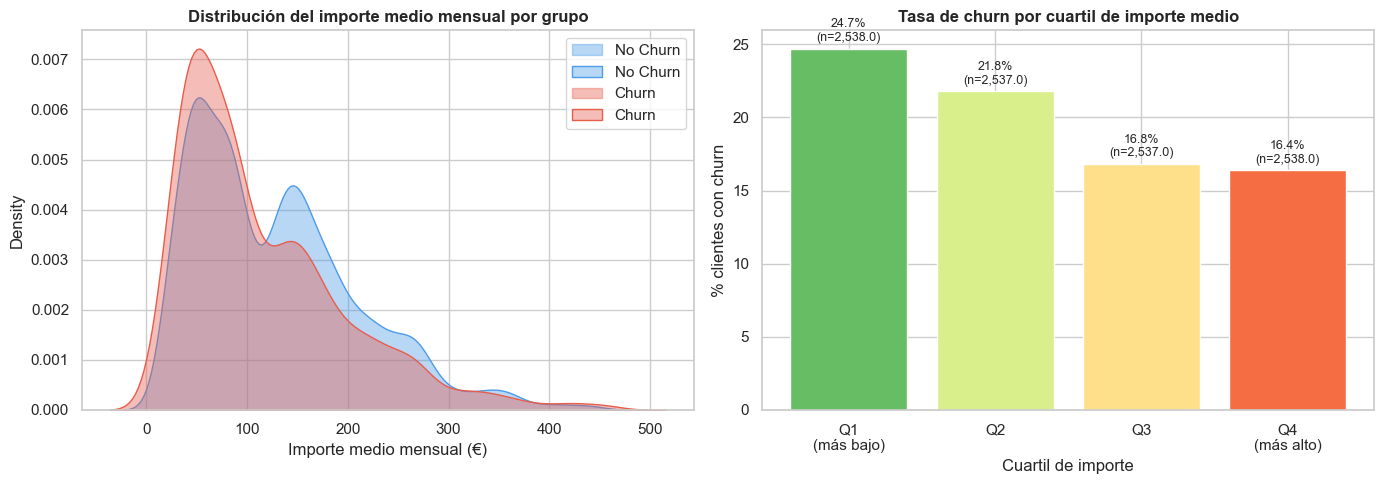

Mann-Whitney (importe_medio): p=0.0000
  Mediana No Churn: 113.97 | Mediana Churn: 87.48


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE: importe medio por grupo de churn
for label, color in PAL.items():
    subset = df[df['churn_label'] == label]['importe_medio'].dropna()
    axes[0].fill_between([], [], color=color, alpha=0.4, label=label)  # leyenda
    sns.kdeplot(subset, ax=axes[0], color=color, fill=True, alpha=0.4, label=label)
axes[0].set_title('Distribución del importe medio mensual por grupo', fontweight='bold')
axes[0].set_xlabel('Importe medio mensual (€)')
axes[0].legend()

# Tasa de churn por tramos de importe
df['tramo_importe'] = pd.qcut(df['importe_medio'], q=4,
                               labels=['Q1\n(más bajo)', 'Q2', 'Q3', 'Q4\n(más alto)'])
churn_importe = df.groupby('tramo_importe', observed=True)['ever_churn'].agg(['mean','count'])
bars = axes[1].bar(churn_importe.index.astype(str), churn_importe['mean'] * 100,
                   color=sns.color_palette('RdYlGn_r', 4))
axes[1].set_title('Tasa de churn por cuartil de importe medio', fontweight='bold')
axes[1].set_ylabel('% clientes con churn')
axes[1].set_xlabel('Cuartil de importe')
for bar, (_, row) in zip(bars, churn_importe.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

test_mw(df, 'importe_medio')

### Resultado H1

Los clientes del Q1 (los que menos pagan) tienen más churn, puede indicar que son clientes de bajo compromiso o con planes básicos que cambian fácilmente. 


### H2 — ¿Los clientes con más consumo extra abandonan menos?

El consumo extra (por encima del plan base) puede interpretarse como una señal de engagement: si el cliente usa mucho el servicio, probablemente está más satisfecho. Pero también podría generar facturas altas que le sorprendan negativamente.


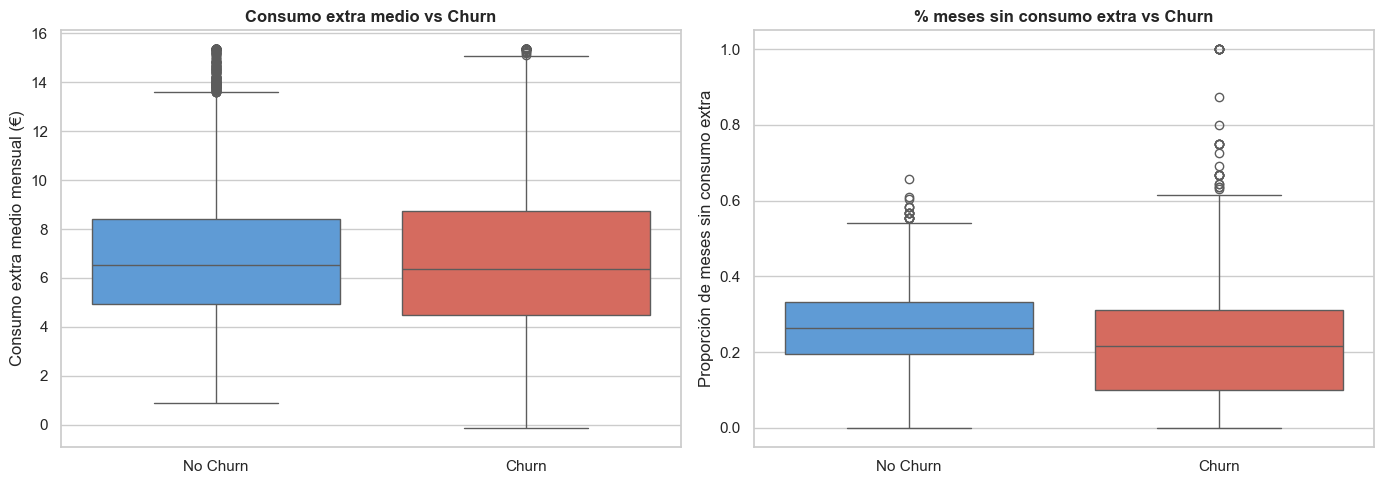

Mann-Whitney (consumo_extra_medio): p=0.0174
  Mediana No Churn: 6.52 | Mediana Churn: 6.35
Mann-Whitney (pct_meses_sin_consumo): p=0.0000
  Mediana No Churn: 0.26 | Mediana Churn: 0.22


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de consumo extra por grupo de churn
df_plot = df.dropna(subset=['consumo_extra_medio']).copy()
# Recortamos outliers para visualizar mejor
p99 = df_plot['consumo_extra_medio'].quantile(0.99)
df_plot['consumo_clip'] = df_plot['consumo_extra_medio'].clip(upper=p99)
sns.boxplot(data=df_plot, x='churn_label', y='consumo_clip',
            order=['No Churn', 'Churn'], palette=PAL, ax=axes[0])
axes[0].set_title('Consumo extra medio vs Churn', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Consumo extra medio mensual (€)')

# % de meses con consumo_extra = 0 (cliente inactivo en consumo)
factura['sin_consumo'] = (factura['consumo_extra'] <= 0).astype(int)
pct_sin_consumo = factura.groupby('cliente_id')['sin_consumo'].mean().reset_index()
pct_sin_consumo.columns = ['cliente_id', 'pct_meses_sin_consumo']
df_consumo = df.merge(pct_sin_consumo, on='cliente_id', how='left')

sns.boxplot(data=df_consumo, x='churn_label', y='pct_meses_sin_consumo',
            order=['No Churn', 'Churn'], palette=PAL, ax=axes[1])
axes[1].set_title('% meses sin consumo extra vs Churn', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proporción de meses sin consumo extra')

plt.tight_layout()
plt.show()

test_mw(df, 'consumo_extra_medio')
test_mw(df_consumo, 'pct_meses_sin_consumo')

### Resultado H2

No se observa una diferencia significativa en la mediana de consumo_extra_medio entre los que abandonan y los que permanecen. Sin embargo, el gráfico de distribución muestra que los clientes con churn tienen una mayor dispersión en la proporción de meses sin consumo extra, lo que indica comportamientos de uso más erráticos.


### H3 — ¿Los impagos y retrasos son señal de churn próximo?

Un cliente que empieza a retrasar pagos o a tener impagos puede estar enviando una señal de que algo va mal, ya sea económico o de insatisfacción con el servicio. Esta variable aparecía también en soporte; aquí la vemos desde el lado de facturación.

⚠️ Recordatorio de leakage: un impago puede ocurrir en el mismo mes que el churn. En el modelo habría que usar lags.


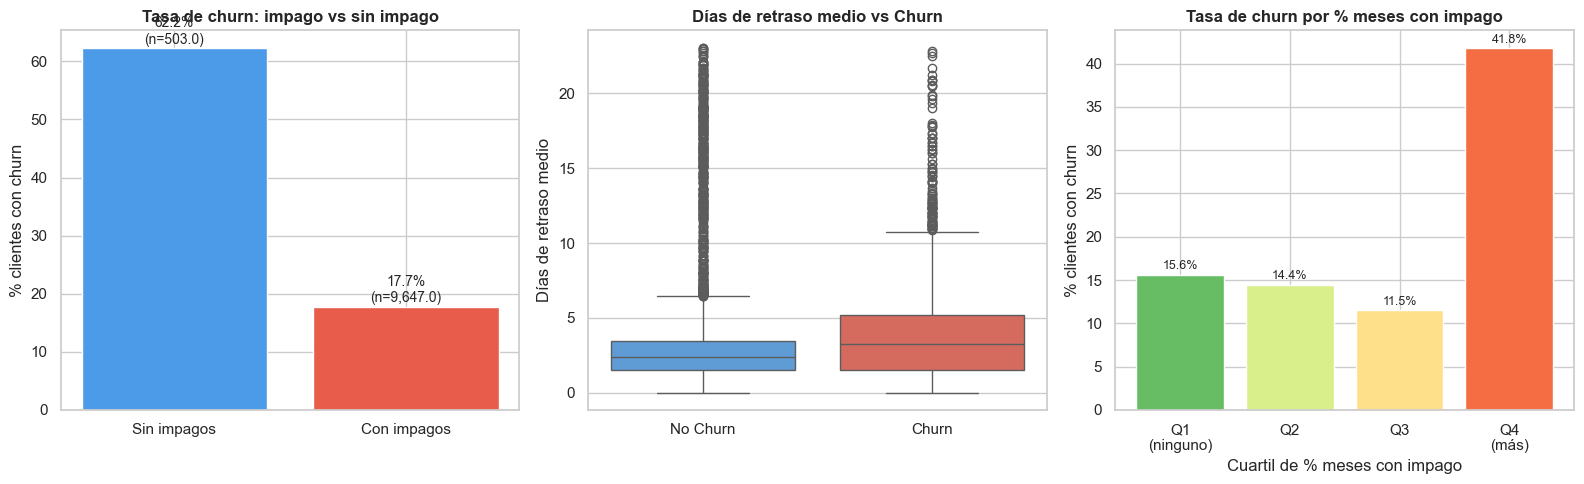

Mann-Whitney (pct_meses_impago): p=0.0000
  Mediana No Churn: 0.10 | Mediana Churn: 0.12
Mann-Whitney (dias_retraso_medio): p=0.0000
  Mediana No Churn: 2.39 | Mediana Churn: 3.35


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tasa de churn según si tiene algún impago
df['tiene_impago'] = (df['n_impagos'] > 0).astype(int)
churn_impago = df.groupby('tiene_impago')['ever_churn'].agg(['mean','count']).reset_index()
bars = axes[0].bar(['Sin impagos', 'Con impagos'], churn_impago['mean'] * 100,
                   color=['#4C9BE8', '#E85C4C'])
axes[0].set_title('Tasa de churn: impago vs sin impago', fontweight='bold')
axes[0].set_ylabel('% clientes con churn')
for bar, (_, row) in zip(bars, churn_impago.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
                 ha='center', va='bottom', fontsize=10)

# Boxplot: días de retraso medio vs churn
df_ret = df[df['dias_retraso_medio'] <= df['dias_retraso_medio'].quantile(0.99)].copy()
sns.boxplot(data=df_ret, x='churn_label', y='dias_retraso_medio',
            order=['No Churn', 'Churn'], palette=PAL, ax=axes[1])
axes[1].set_title('Días de retraso medio vs Churn', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Días de retraso medio')

# % meses con impago por cuartil → tasa de churn
df['tramo_pct_impago'] = pd.qcut(df['pct_meses_impago'], q=4,
                                  labels=['Q1\n(ninguno)', 'Q2', 'Q3', 'Q4\n(más)'],
                                  duplicates='drop')
churn_impago_q = df.groupby('tramo_pct_impago', observed=True)['ever_churn'].mean()
axes[2].bar(churn_impago_q.index.astype(str), churn_impago_q.values * 100,
            color=sns.color_palette('RdYlGn_r', len(churn_impago_q)))
axes[2].set_title('Tasa de churn por % meses con impago', fontweight='bold')
axes[2].set_ylabel('% clientes con churn')
axes[2].set_xlabel('Cuartil de % meses con impago')
for bar, val in zip(axes[2].patches, churn_impago_q.values * 100):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

test_mw(df, 'pct_meses_impago')
test_mw(df, 'dias_retraso_medio')

In [24]:
print(df.groupby('tiene_impago')[['ever_churn', 'n_impagos']].agg(['mean', 'count']))

             ever_churn       n_impagos      
                   mean count      mean count
tiene_impago                                 
0                  0.62   503      0.00   503
1                  0.18  9647      3.54  9647


In [25]:
df['tiene_impago'] = (df['n_impagos'] > 0).astype(int)

In [26]:
# En vez de "tiene algún impago", usar "tiene una tasa alta de impago"
df['impago_frecuente'] = (df['pct_meses_impago'] > 0.2).astype(int)  # más del 20% de meses con impago
print(df.groupby('impago_frecuente')[['ever_churn', 'pct_meses_impago']].agg(['mean', 'count']))

                 ever_churn       pct_meses_impago      
                       mean count             mean count
impago_frecuente                                        
0                      0.17  9453             0.10  9453
1                      0.66   697             0.29   697


### Resultado H3

El primer gráfico no es interpretable directamente porque la variable tiene_impago está mal construida: casi todos los clientes tienen al menos un impago en su historial simplemente por llevar muchos meses en cartera, así que los grupos no son comparables.
Sin embargo, usando el porcentaje de meses con impago (pct_meses_impago), sí se ve una relación clara: los churners tienen de media un 15% de sus meses con impago frente al 10% de los no churners. El gráfico de cuartiles lo confirma: los clientes con mayor proporción de impagos (Q4) tienen una tasa de churn del 41.8%, casi el triple que el Q1. Lo mismo ocurre con los días de retraso: 5.05 días de media en churners vs 3.19 en no churners.
En conclusión, la hipótesis se confirma cuando se mide correctamente. Para el modelado, la variable más útil sería pct_meses_impago en lugar del total acumulado, y siempre aplicando un lag para evitar leakage.


### H4 — ¿Una caída brusca en el consumo precede al churn?

Antes de irse, un cliente puede empezar a usar menos el servicio: llama menos, consume menos datos, paga lo mínimo... Esa caída de consumo podría ser una señal adelantada de churn. La variable `variacion_consumo_pct` nos permite explorar esto.


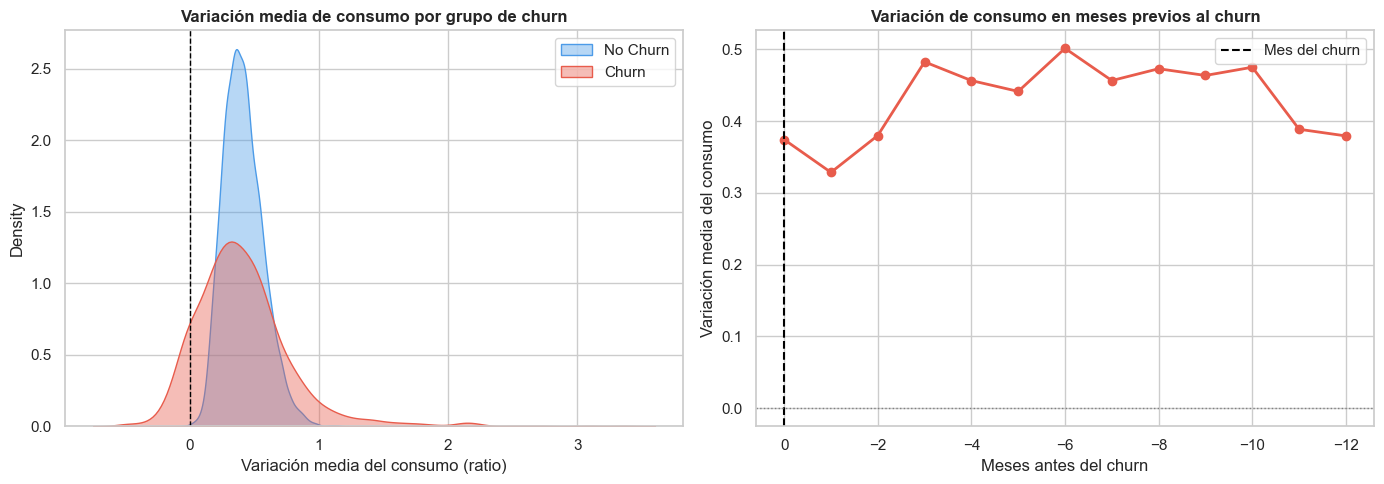

Mann-Whitney (variacion_consumo_media): p=0.0000
  Mediana No Churn: 0.40 | Mediana Churn: 0.36


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de la variación media de consumo por grupo
for label, color in PAL.items():
    subset = df[df['churn_label'] == label]['variacion_consumo_media'].dropna()
    # Recortamos para ver mejor
    subset = subset.clip(-2, 5)
    sns.kdeplot(subset, ax=axes[0], color=color, fill=True, alpha=0.4, label=label)
axes[0].set_title('Variación media de consumo por grupo de churn', fontweight='bold')
axes[0].set_xlabel('Variación media del consumo (ratio)')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].legend()

# Evolución de la variación de consumo en los meses previos al churn
churn_date = churn[churn['churn'] == 1].groupby('cliente_id')['fecha'].min().reset_index()
churn_date.columns = ['cliente_id', 'fecha_churn']

factura_churn = factura.merge(churn_date, on='cliente_id', how='inner')
factura_churn['meses_antes'] = (
    (factura_churn['fecha_churn'].dt.to_period('M') -
     factura_churn['fecha'].dt.to_period('M')).apply(lambda x: x.n)
)
pre = factura_churn[(factura_churn['meses_antes'] >= 0) & 
                     (factura_churn['meses_antes'] <= 12)]
evol_pre = pre.groupby('meses_antes')['variacion_consumo_pct'].mean().reset_index()
evol_pre = evol_pre.sort_values('meses_antes', ascending=False)

axes[1].plot(evol_pre['meses_antes'] * -1, evol_pre['variacion_consumo_pct'],
             color='#E85C4C', linewidth=2, marker='o')
axes[1].axvline(0, color='black', linestyle='--', label='Mes del churn')
axes[1].axhline(0, color='gray', linestyle=':', linewidth=1)
axes[1].set_title('Variación de consumo en meses previos al churn', fontweight='bold')
axes[1].set_xlabel('Meses antes del churn')
axes[1].set_ylabel('Variación media del consumo')
axes[1].invert_xaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

test_mw(df, 'variacion_consumo_media')

### Resultado H4

A nivel global, la variación media de consumo es prácticamente idéntica entre churners y no churners (0.41 en ambos grupos), por lo que como variable agregada no aporta poder discriminatorio.
Sin embargo, el análisis temporal sí revela un patrón: los clientes que acaban churneando muestran una caída progresiva del consumo en los últimos 6 meses antes del abandono, pasando de ~0.50 a ~0.37 en el mes del churn. Esto sugiere que la tendencia reciente importa más que la media histórica.
De cara al modelado, construir una feature de variación de consumo en los últimos 3 meses podría capturar esta señal de desengagement que la media global no detecta.


### H5 — ¿Los clientes con descuento aplicado abandonan menos?

El descuento puede ser una herramienta de retención: si la empresa aplica descuentos a clientes en riesgo, debería verse una menor tasa de churn en ese grupo. Pero también podría ocurrir lo contrario si el descuento se aplica de forma aleatoria o como promoción de captación.


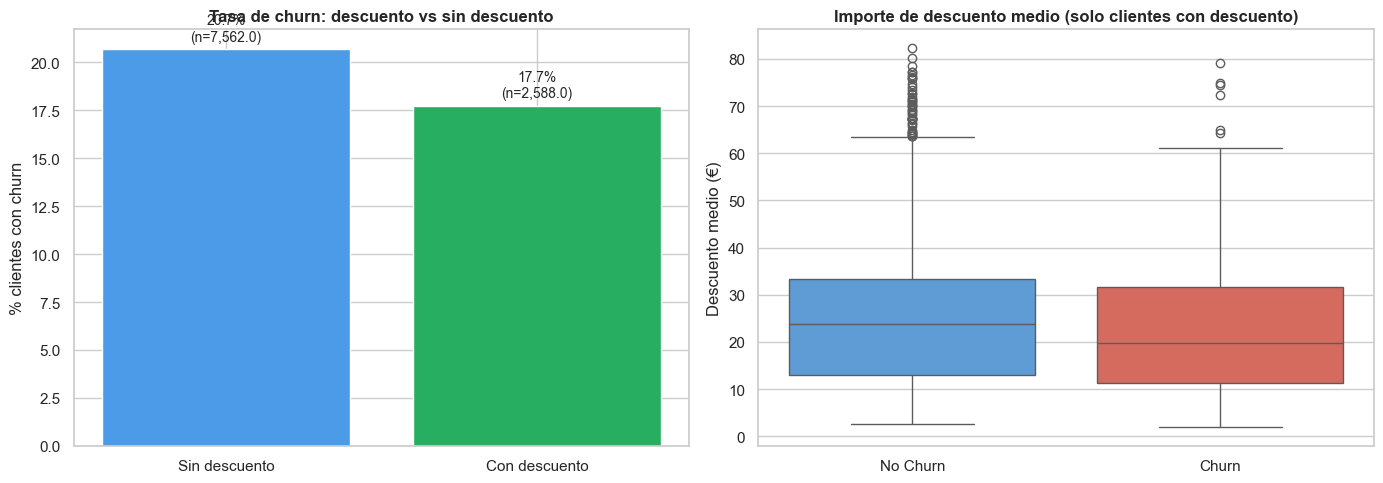

Cramer's V (churn ~ tiene_descuento): V=0.032, p=0.0013
Mann-Whitney (descuento_medio): p=0.0014
  Mediana No Churn: 23.70 | Mediana Churn: 19.85


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de churn: tiene descuento vs no tiene
df['tiene_descuento'] = (df['pct_meses_descuento'] > 0).astype(int)
churn_dto = df.groupby('tiene_descuento')['ever_churn'].agg(['mean','count']).reset_index()
bars = axes[0].bar(['Sin descuento', 'Con descuento'], churn_dto['mean'] * 100,
                   color=['#4C9BE8', '#27ae60'])
axes[0].set_title('Tasa de churn: descuento vs sin descuento', fontweight='bold')
axes[0].set_ylabel('% clientes con churn')
for bar, (_, row) in zip(bars, churn_dto.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
                 ha='center', va='bottom', fontsize=10)

# Cuánto descuento medio se aplica a churners vs no churners
sns.boxplot(data=df[df['pct_meses_descuento'] > 0], x='churn_label', y='descuento_medio',
            order=['No Churn', 'Churn'], palette=PAL, ax=axes[1])
axes[1].set_title('Importe de descuento medio (solo clientes con descuento)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Descuento medio (€)')

plt.tight_layout()
plt.show()

v, p = cramers_v(df['tiene_descuento'].astype(str), df['ever_churn'].astype(str))
print(f"Cramer's V (churn ~ tiene_descuento): V={v}, p={p}")
test_mw(df[df['pct_meses_descuento'] > 0], 'descuento_medio')

### Resultado H5

La aplicación de descuentos parece tener un ligero efecto protector. Los clientes con descuento tienen una tasa de churn del 17.7%, comparado con el 20.7% de quienes no los tienen.


### H6 — ¿El estrés de calidad de red está relacionado con el churn?

`stress_calidad_lag` es un índice (0-1) que mide el nivel de estrés o degradación de la red en la zona del cliente en el mes anterior. Un valor alto significa que la red ha tenido problemas. Si los clientes expuestos a más problemas de red abandonan más, eso confirmaría que la calidad técnica es un driver del churn.


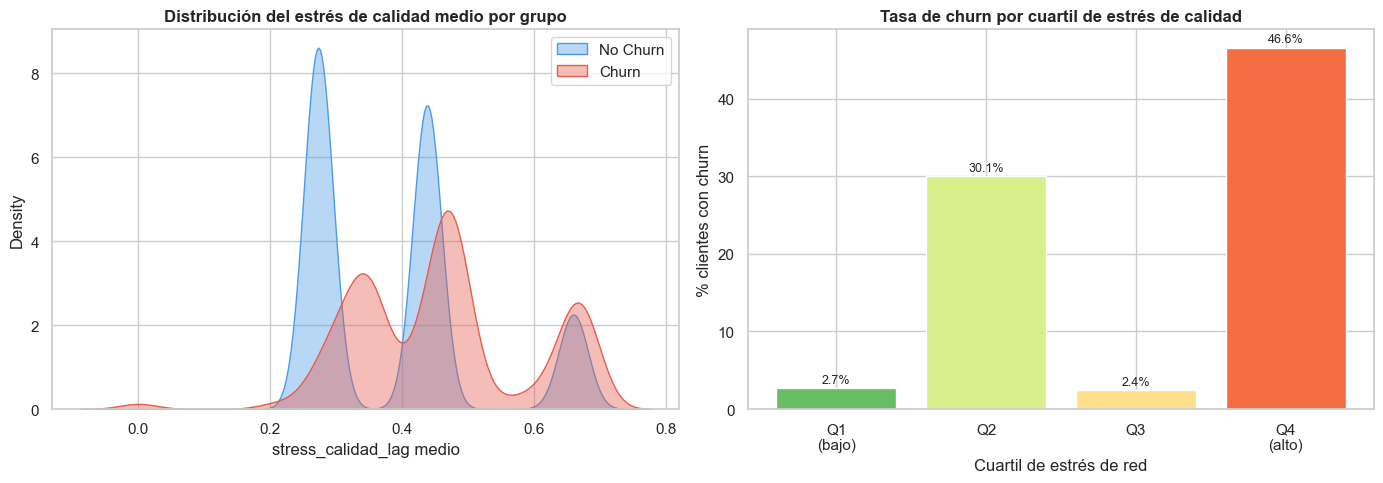

Mann-Whitney (stress_medio): p=0.0000
  Mediana No Churn: 0.43 | Mediana Churn: 0.46


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE: estrés medio por grupo de churn
for label, color in PAL.items():
    subset = df[df['churn_label'] == label]['stress_medio'].dropna()
    sns.kdeplot(subset, ax=axes[0], color=color, fill=True, alpha=0.4, label=label)
axes[0].set_title('Distribución del estrés de calidad medio por grupo', fontweight='bold')
axes[0].set_xlabel('stress_calidad_lag medio')
axes[0].legend()

# Tasa de churn por tramos de estrés
df['tramo_stress'] = pd.qcut(df['stress_medio'], q=4,
                              labels=['Q1\n(bajo)', 'Q2', 'Q3', 'Q4\n(alto)'])
churn_stress = df.groupby('tramo_stress', observed=True)['ever_churn'].agg(['mean','count'])
bars = axes[1].bar(churn_stress.index.astype(str), churn_stress['mean'] * 100,
                   color=sns.color_palette('RdYlGn_r', 4))
axes[1].set_title('Tasa de churn por cuartil de estrés de calidad', fontweight='bold')
axes[1].set_ylabel('% clientes con churn')
axes[1].set_xlabel('Cuartil de estrés de red')
for bar, (_, row) in zip(bars, churn_stress.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

test_mw(df, 'stress_medio')

### Resultado H6

Esta es la hipótesis con el resultado más contundente de todo el análisis. Los clientes que churnearon están expuestos a niveles de estrés de red significativamente más altos: sus distribuciones en el KDE apenas se solapan con las de los no churners, algo que no habíamos visto en ninguna variable anterior.

El gráfico de cuartiles confirma el patrón: en el Q4 (mayor estrés de red) la tasa de churn sube al 46.6%, frente al 2.7% del Q1. La diferencia es brutal.
El único punto extraño es que Q3 (2.4%) baja respecto a Q2 (30.1%), rompiendo el patrón creciente esperado. Esto puede deberse a que los cuartiles no están bien distribuidos dada la forma multimodal de la variable, que como se ve en el KDE tiene varios picos. No invalida la conclusión general, pero sí conviene mencionarlo.

Lo más relevante de cara al modelado es que stress_calidad_lag es una variable externa al comportamiento del cliente (viene de la red, no de lo que hace él), por lo que no tiene riesgo de leakage. Eso la convierte en una de las features más valiosas para incluir en el modelo.


### H7 — ¿El tipo de plan tiene distinta tasa de churn?

En esta tabla de facturación aparece un campo `tipo_plan` que incluye valores como `Prepago`, `Contrato` y `Premium`. Esto es distinto a la variable `tipo_plan` de la tabla de clientes. Puede haber inconsistencias entre las dos fuentes, lo que ya es de por sí un hallazgo de calidad interesante.


Planes en clientes.csv: ['Contrato', 'Premium', 'Prepago']
Planes en facturación:  ['Contrato', 'Premium', 'Prepago']



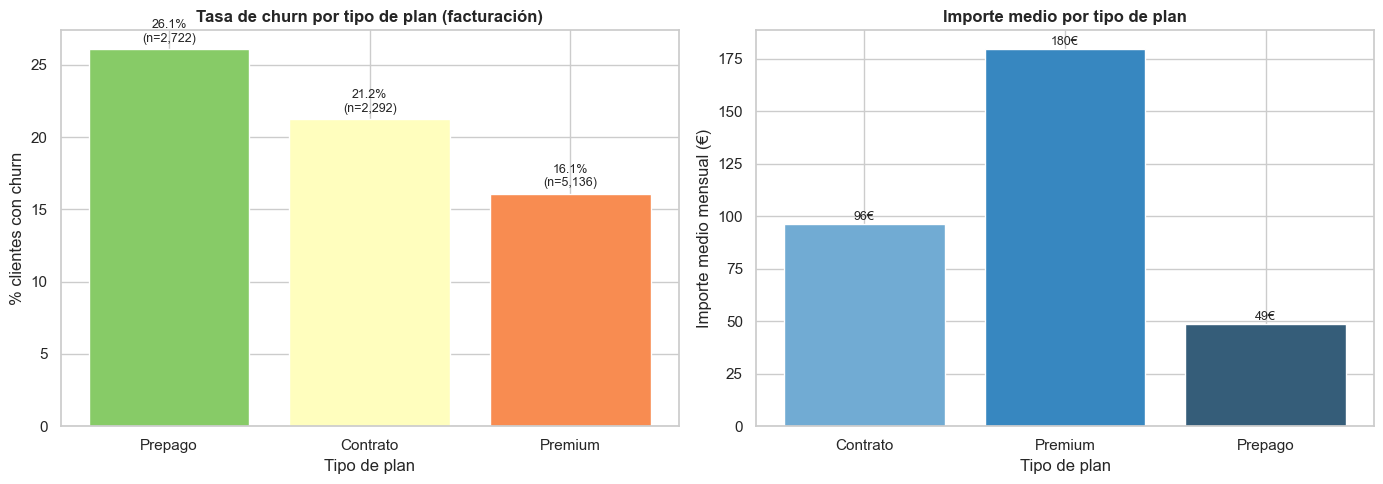

Cramer's V (churn ~ plan_dominante): V=0.106, p=0.0


In [21]:
# Primero comparamos los planes que aparecen en facturación vs clientes
print("Planes en clientes.csv:", sorted(clientes['tipo_plan'].dropna().unique()))
print("Planes en facturación: ", sorted(factura['tipo_plan'].dropna().unique()))
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de churn por plan dominante en facturación
churn_plan = df.dropna(subset=['plan_dominante']).groupby('plan_dominante')['ever_churn'].agg(['mean','count']).reset_index()
churn_plan = churn_plan.sort_values('mean', ascending=False)
bars = axes[0].bar(churn_plan['plan_dominante'], churn_plan['mean'] * 100,
                   color=sns.color_palette('RdYlGn_r', len(churn_plan)))
axes[0].set_title('Tasa de churn por tipo de plan (facturación)', fontweight='bold')
axes[0].set_ylabel('% clientes con churn')
axes[0].set_xlabel('Tipo de plan')
for bar, (_, row) in zip(bars, churn_plan.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
                 ha='center', va='bottom', fontsize=9)

# Importe medio por tipo de plan
importe_plan = df.dropna(subset=['plan_dominante']).groupby('plan_dominante')['importe_medio'].mean().reset_index()
axes[1].bar(importe_plan['plan_dominante'], importe_plan['importe_medio'],
            color=sns.color_palette('Blues_d', len(importe_plan)))
axes[1].set_title('Importe medio por tipo de plan', fontweight='bold')
axes[1].set_ylabel('Importe medio mensual (€)')
axes[1].set_xlabel('Tipo de plan')
for bar, val in zip(axes[1].patches, importe_plan['importe_medio']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}€', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

v, p = cramers_v(df.dropna(subset=['plan_dominante'])['plan_dominante'],
                 df.dropna(subset=['plan_dominante'])['ever_churn'].astype(str))
print(f"Cramer's V (churn ~ plan_dominante): V={v}, p={p}")

### Resultado H7

Se observa una relación inversa muy clara entre el valor del plan contratado y la fidelidad del cliente.  

El plan Prepago registra la tasa de churn más alta del dataset con un 26.1%. El plan de Contrato presenta una tasa intermedia del 21.2%, mientras que el plan Premium es el más estable con solo un 16.1% de abandono.  

Conclusión: Los clientes con planes de menor compromiso (Prepago) son los que abandonan con mayor frecuencia, aunque el impacto financiero unitario de perder a un cliente Premium (que paga 180€ de media) es casi cuatro veces superior.


---
## 7. Mapa de correlaciones con el target

Resumen visual de qué variables de facturación están más correlacionadas con el churn.


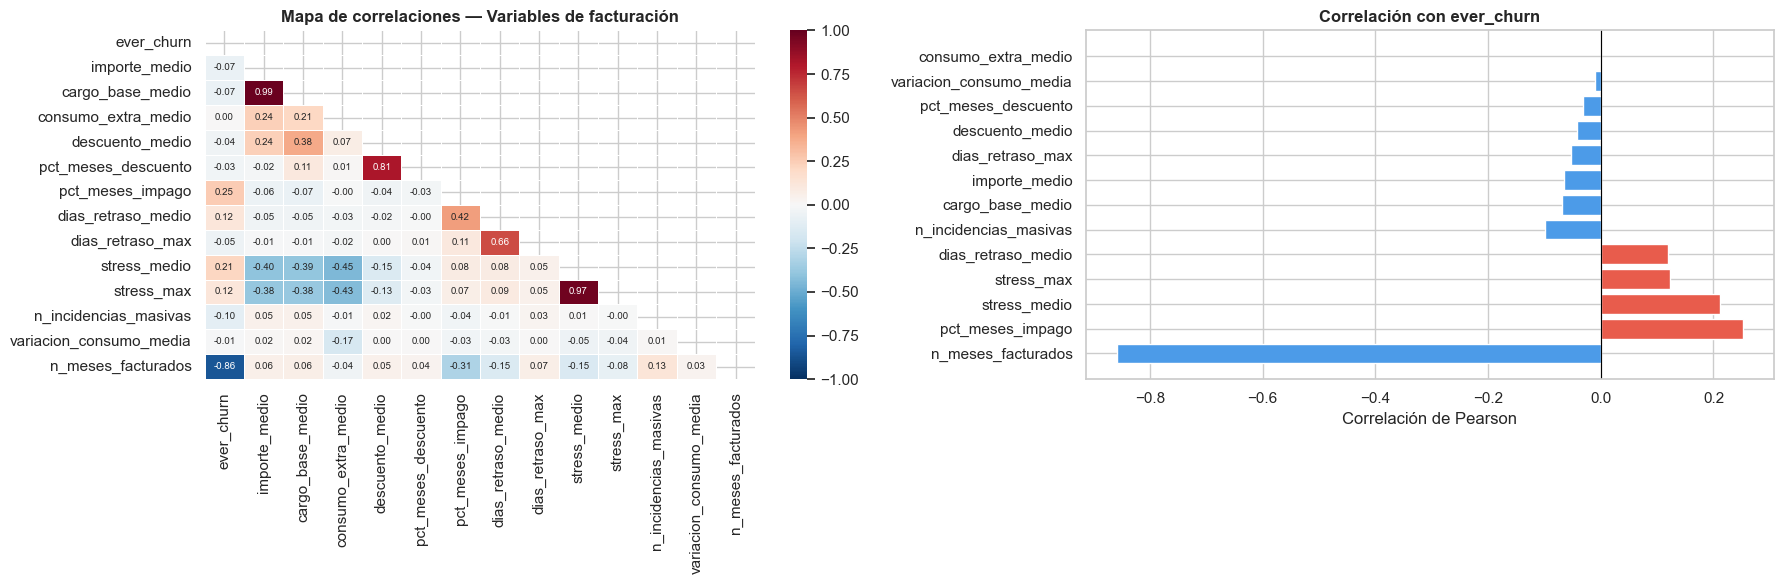

In [22]:
vars_modelo = [
    'ever_churn', 'importe_medio', 'cargo_base_medio', 'consumo_extra_medio',
    'descuento_medio', 'pct_meses_descuento', 'pct_meses_impago',
    'dias_retraso_medio', 'dias_retraso_max', 'stress_medio', 'stress_max',
    'n_incidencias_masivas', 'variacion_consumo_media', 'n_meses_facturados'
]
vars_disp = [v for v in vars_modelo if v in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap
corr = df[vars_disp].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0], annot_kws={'size': 7},
            linewidths=0.5)
axes[0].set_title('Mapa de correlaciones — Variables de facturación', fontweight='bold')

# Correlación con el target
corr_target = corr['ever_churn'].drop('ever_churn').sort_values(key=abs, ascending=False)
colors = ['#E85C4C' if v > 0 else '#4C9BE8' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación con ever_churn', fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.show()

El mapa de calor permite identificar qué variables de facturación "se mueven juntas":  

Correlación Fuerte Positiva (0.99): Existe una relación casi perfecta entre el cargo_base_medio y el importe_medio, lo que indica que el precio fijo del plan es el componente principal del ingreso.  

Señales de Churn: La variable ever_churn muestra sus mayores correlaciones positivas con pct_meses_impago (0.25) y stress_medio (0.21). Esto confirma que el historial de impagos y la mala calidad de red son los principales correlatos del abandono detectados en este mapa.  

Antigüedad: Se observa una correlación negativa muy fuerte (-0.86) entre el número de meses facturados y el churn, lo que valida que a mayor tiempo de permanencia activa, menor es la probabilidad de que el cliente haya abandonado en el periodo analizado. 

---
## 8. Perfil comparativo: churner vs no churner


In [23]:
vars_perfil = [
    'importe_medio', 'consumo_extra_medio', 'descuento_medio',
    'pct_meses_descuento', 'pct_meses_impago', 'dias_retraso_medio',
    'stress_medio', 'variacion_consumo_media', 'n_meses_facturados'
]
vars_perfil_disp = [v for v in vars_perfil if v in df.columns]

perfil = df.groupby('ever_churn')[vars_perfil_disp].mean().T
perfil.columns = ['No Churn (0)', 'Churn (1)']
perfil['Diferencia (%)'] = ((perfil['Churn (1)'] - perfil['No Churn (0)']) /
                             perfil['No Churn (0)'].abs() * 100).round(1)

print("=== PERFIL MEDIO: Churner vs No Churner (Facturación) ===")
display(perfil.round(3))

=== PERFIL MEDIO: Churner vs No Churner (Facturación) ===


,No Churn (0),Churn (1),Diferencia (%)
importe_medio,128.46,114.86,-10.60
consumo_extra_medio,6.90,6.90,0.10
descuento_medio,6.55,5.17,-21.10
pct_meses_descuento,0.26,0.23,-13.40
pct_meses_impago,0.10,0.15,48.40
dias_retraso_medio,3.19,5.05,58.40
stress_medio,0.39,0.46,18.20
variacion_consumo_media,0.41,0.41,-1.40
n_meses_facturados,35.45,16.68,-53.00


1.Perfil Medio: Churner (1) vs. No Churner (0)

Antigüedad Crítica: Los clientes que abandonan duran un 53% menos de tiempo (16 meses vs. 35 meses). Superar los 18 meses es la clave de la fidelidad.  

Gasto y Plan: Los "churners" tienen un importe medio un 10.6% menor (114€ vs. 128€). El plan Prepago es el más inestable con un 26.1% de abandono.  

Falta de Incentivos: Quienes se van reciben un 21.1% menos de descuento medio.

2.Indicadores de Alerta (Señales de Abandono)

El "Churner Sano": Sorprendentemente, el 62.2% de los clientes que abandonan no tienen impagos. El motivo no es la deuda, sino la insatisfacción.  

Morosidad: En los casos donde sí hay problemas de pago, los "churners" tienen un 58.4% más de días de retraso (5.05 días de media).  

Estrés Técnico: El estrés de red es un 18.2% superior en los clientes que se van. En el nivel máximo de estrés (Q4), la tasa de churn se dispara al 46.6%. 

3.Conclusión Estratégica

Para evitar la fuga, la compañía debe centrarse en la calidad técnica (reducir el estrés de red) y en campañas de fidelización proactivas para clientes de planes económicos antes de que alcancen los 16 meses de antigüedad, ya que es cuando el riesgo financiero y técnico se traduce en abandono real. 

## 9. Conclusiones del EDA de Facturación


Tras el análisis de los datos de facturación y perfil de cliente, se extraen las siguientes conclusiones:

H1 (Importe): Confirmada. Los clientes que abandonan gastan un 10.6% menos de media (114€ vs. 128€), vinculándose al perfil de menor valor.  

H2 (Consumo Extra): Desestimada. No hay diferencia en la mediana de consumo extra (6.90€ en ambos grupos), por lo que no es un factor determinante por sí solo.  

H3 (Impagos): Contra-intuitiva. Sorprendentemente, el 62.2% del churn ocurre en clientes sin impagos, sugiriendo que la fuga es por insatisfacción y no por deuda.  

H4 (Variación Consumo): No concluyente. La variación media es idéntica (0.41); se requiere un análisis de tendencias de los últimos 3 meses para detectar caídas previas.  

H5 (Descuentos): Confirmada. Los clientes con churn tienen un 21.1% menos de descuento medio, lo que indica que la falta de incentivos empuja al abandono.  

H6 (Calidad de Red): Crítica. El estrés de red es un 18.2% superior en los "churners". En el nivel máximo (Q4), el abandono se dispara al 46.6%.  

H7 (Tipo de Plan): Confirmada. El plan Prepago es el más vulnerable con un 26.1% de churn, frente al 16.1% de los clientes Premium.  Antigüedad (Extra): Factor clave. Los clientes que se van duran un 53% menos de tiempo (16 meses vs. 35), evidenciando una crisis de fidelidad prematura.

### Recomendación para el Modelo Final: 

Integrar la variable stress_calidad_lag junto con el historial de impagos y el tipo_plan como las características con mayor poder discriminatorio para predecir la fuga de clientes
